In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-Learn Modules
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_recall_curve,
    precision_score,
    recall_score,
    fbeta_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    brier_score_loss
)

# Explainability & Persistence
import shap
import joblib

# Aesthetic Plot Styling Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['figure.dpi'] = 110

Data Ingestion & Feature Engineering

We load `dataset.csv` and apply the engineered risk signals identified during Exploratory Data Analysis and Model Validation:
- `log_amount_usd`: Logarithmic transformation ($\log(1 + x)$) of transaction amount to normalize heavy right-skew.
- `cumulitative_risk_factor`: Count of simultaneous high-risk indicator flags (`used_vpn`, `ip_country_mismatch`, `billing_shipping_mismatch`, `is_foreign_transaction`, `is_ai_generated_scam_attempt`, `is_new_merchant`).
- `amount_to_balance_ratio`: Relative spend size against account liquidity.
- `velocity_to_gap_ratio`: Ratio of transaction velocity score to inter-transaction recency hours.
- `is_high_risk_merchant`: Categorical flag for high-chargeback categories (`Crypto Exchange`, `Gift Cards`, `Gaming`).
- `is_aunthenticated`: Indicator flag for transactions lacking 3DS/OTP verification (`No Authentication`).

In [24]:
# Ingest dataset
df = pd.read_csv("dataset.csv")

# Feature Engineering
df['log_amount_usd'] = np.log1p(df['amount_usd'])
df['cumulitative_risk_factor'] = df[
    ['used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 
     'is_foreign_transaction', 'is_ai_generated_scam_attempt', 'is_new_merchant']
].sum(axis=1)
df['amount_to_balance_ratio'] = df['amount_usd'] / (df['account_balance_usd'] + 1)
df['velocity_to_gap_ratio'] = df['velocity_score'] / (df['hours_since_last_txn'] + 0.1)

high_risk_merchants = ['Crypto Exchange', 'Gift Cards', 'Gaming']
df['is_high_risk_merchant'] = df['merchant_category'].isin(high_risk_merchants)
df['is_aunthenticated'] = df['auth_method'] == 'No Authentication'

# Define Feature Matrix (X) and Target (y)
drop_cols = ['transaction_id', 'is_fraud', 'amount_usd', 'account_balance_usd', 'velocity_score']
X = df.drop(columns=drop_cols)
y = df['is_fraud']

categorical_cols = ['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type']
numerical_cols = [c for c in X.columns if c not in categorical_cols]

# Build Preprocessor Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    verbose_feature_names_out=False
)

# 80/20 Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f" Total Transactions: {len(df):,}")
print(f" Training Set:       {X_train.shape[0]:,} samples | Fraud rate: {y_train.mean():.2%}")
print(f" Holdout Test Set:   {X_test.shape[0]:,} samples | Fraud rate: {y_test.mean():.2%}")
print(f" Input Features:     {len(numerical_cols)} numerical + {len(categorical_cols)} categorical")

 Total Transactions: 20,000
 Training Set:       16,000 samples | Fraud rate: 1.69%
 Holdout Test Set:   4,000 samples | Fraud rate: 1.70%
 Input Features:     22 numerical + 5 categorical


Baseline Logistic Regression Benchmark

We establish baseline performance using default `LogisticRegression(class_weight='balanced', random_state=42)` across 5-Fold Stratified Cross-Validation on the training partition and evaluate out-of-sample generalization on the holdout test set.

In [25]:
# Baseline Logistic Regression Pipeline
baseline_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# 5-Fold Stratified Cross Validation on Train Set
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_pr_aucs = []
cv_roc_aucs = []

for fold, (t_idx, v_idx) in enumerate(skf.split(X_train, y_train), 1):
    X_tr_fold, X_val_fold = X_train.iloc[t_idx], X_train.iloc[v_idx]
    y_tr_fold, y_val_fold = y_train.iloc[t_idx], y_train.iloc[v_idx]
    
    baseline_pipeline.fit(X_tr_fold, y_tr_fold)
    val_probs = baseline_pipeline.predict_proba(X_val_fold)[:, 1]
    
    cv_pr_aucs.append(average_precision_score(y_val_fold, val_probs))
    cv_roc_aucs.append(roc_auc_score(y_val_fold, val_probs))

# Fit on full train and evaluate on holdout test
baseline_pipeline.fit(X_train, y_train)
y_test_probs_base = baseline_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_base = baseline_pipeline.predict(X_test)

base_test_prauc = average_precision_score(y_test, y_test_probs_base)
base_test_rocauc = roc_auc_score(y_test, y_test_probs_base)
base_test_f1 = f1_score(y_test, y_test_pred_base, zero_division=0)
base_test_f2 = fbeta_score(y_test, y_test_pred_base, beta=2, zero_division=0)
base_test_rec = recall_score(y_test, y_test_pred_base, zero_division=0)
base_test_prec = precision_score(y_test, y_test_pred_base, zero_division=0)

baseline_summary = pd.DataFrame({
    'Metric': ['CV PR-AUC (5-Fold Mean)', 'CV ROC-AUC (5-Fold Mean)', 'Test PR-AUC', 'Test ROC-AUC', 
               'Test Precision (t=0.50)', 'Test Recall (t=0.50)', 'Test F1-Score (t=0.50)', 'Test F2-Score (t=0.50)'],
    'Baseline Score': [
        f"{np.mean(cv_pr_aucs):.4f} ± {np.std(cv_pr_aucs):.4f}",
        f"{np.mean(cv_roc_aucs):.4f} ± {np.std(cv_roc_aucs):.4f}",
        f"{base_test_prauc:.4f}",
        f"{base_test_rocauc:.4f}",
        f"{base_test_prec:.4f}",
        f"{base_test_rec:.4f}",
        f"{base_test_f1:.4f}",
        f"{base_test_f2:.4f}"
    ]
})

print("Baseline Model Performance Summary:")
display(baseline_summary)

Baseline Model Performance Summary:


,Metric,Baseline Score
0,CV PR-AUC (5-Fold Mean),0.3764 ± 0.0573
1,CV ROC-AUC (5-Fold Mean),0.9289 ± 0.0081
2,Test PR-AUC,0.3864
3,Test ROC-AUC,0.9193
4,Test Precision (t=0.50),0.0969
5,Test Recall (t=0.50),0.7794
6,Test F1-Score (t=0.50),0.1724
7,Test F2-Score (t=0.50),0.3236


Systematic Hyperparameter Tuning

We execute a 5-Fold Stratified `GridSearchCV` on the training set to optimize:
1. **Regularization Strength ($C$):** $C \in [0.001, 0.005, 0.01, 0.05, 0.077, 0.1, 0.5, 1.0, 5.0, 10.0]$
   - Controls the inverse regularization penalty. Smaller $C$ enforces stronger penalization to prevent overfitting to rare fraud noise.
2. **Solvers & Penalty Norms:**
   - `lbfgs` with $L_2$ Ridge regularization.
   - `liblinear` with $L_1$ Lasso feature selection.
3. **Class Weighting Schemes:**
   - `None`: Standard maximum likelihood (unweighted).
   - `'balanced'`: Inversely proportional to class frequencies ($w_1 \approx 58$).
   - Custom asymmetric weights: $\{0: 1, 1: 5\}, \{0: 1, 1: 10\}, \{0: 1, 1: 20\}$.
4. **Optimization Target:** **PR-AUC** (`average_precision`), which measures precision across all recall levels under extreme class imbalance without being distorted by the massive true negative class.

In [26]:
# Define Hyperparameter Search Space
param_grid = [
    # L2 Ridge with L-BFGS Solver
    {
        'clf__solver': ['lbfgs'],
        'clf__C': [0.001, 0.005, 0.01, 0.05, 0.077, 0.1, 0.5, 1.0, 5.0, 10.0],
        'clf__class_weight': ['balanced', None, {0: 1, 1: 5}, {0: 1, 1: 10}, {0: 1, 1: 20}]
    },
    # L1 Lasso with Liblinear Solver
    {
        'clf__solver': ['liblinear'],
        'clf__penalty': ['l1'],
        'clf__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0],
        'clf__class_weight': ['balanced', None, {0: 1, 1: 10}]
    }
]

# Pipeline Blueprint
blueprint_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Execute GridSearchCV
grid_search = GridSearchCV(
    estimator=blueprint_pipeline,
    param_grid=param_grid,
    cv=skf,
    scoring='average_precision',
    n_jobs=1,
    return_train_score=True,
    verbose=0
)

print(" Running 5-Fold Stratified GridSearchCV optimization on Logistic Regression...")
grid_search.fit(X_train, y_train)
print(f" Grid Search completed! Evaluated {len(grid_search.cv_results_['params'])} parameter configurations.")

# Best Hyperparameters
best_params = grid_search.best_params_
best_cv_score = grid_search.best_score_
tuned_model = grid_search.best_estimator_

print(f"\n Best 5-Fold CV PR-AUC: {best_cv_score:.4f}")
print(" Best Hyperparameters:")
for param, val in best_params.items():
    print(f"   • {param.replace('clf__', '')}: {val}")

 Running 5-Fold Stratified GridSearchCV optimization on Logistic Regression...
 Grid Search completed! Evaluated 68 parameter configurations.

 Best 5-Fold CV PR-AUC: 0.4076
 Best Hyperparameters:
   • C: 0.05
   • class_weight: None
   • solver: lbfgs


Hyperparameter Sensitivity Analysis


 Top 10 Hyperparameter Configurations:


,C,Solver,Class Weight,Mean CV PR-AUC,Std CV PR-AUC,Mean Train PR-AUC
0,0.050,lbfgs,None,0.4076,0.0551,0.4348
1,0.100,liblinear,None,0.4072,0.0547,0.4171
2,0.077,lbfgs,None,0.4070,0.0529,0.4378
3,0.100,lbfgs,None,0.4070,0.0538,0.4388
4,0.500,liblinear,None,0.4058,0.0519,0.4369
5,0.500,lbfgs,None,0.4047,0.0536,0.4419
6,0.010,lbfgs,"{0: 1, 1: 5}",0.4040,0.0522,0.4224
7,0.005,lbfgs,"{0: 1, 1: 5}",0.4028,0.0533,0.4180
8,1.000,liblinear,None,0.4027,0.0513,0.4408
9,1.000,lbfgs,None,0.4020,0.0495,0.4418


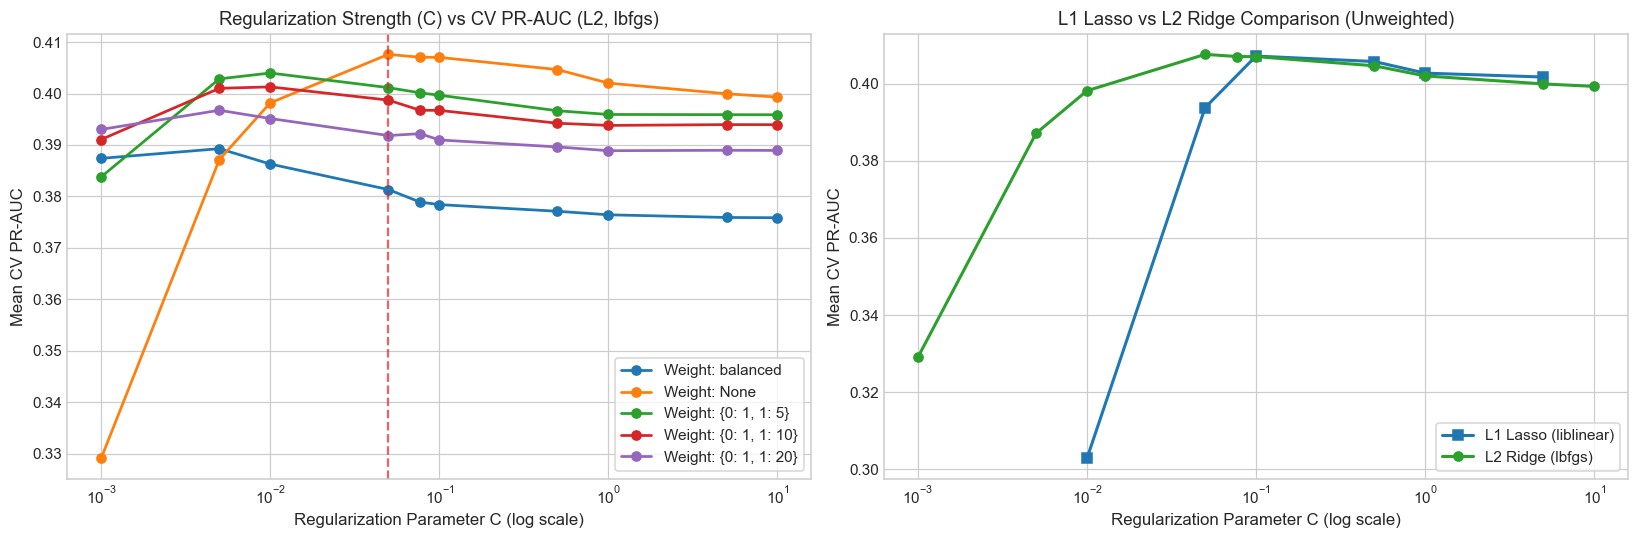

In [27]:
# Extract CV Results into a Clean DataFrame
cv_res = pd.DataFrame(grid_search.cv_results_)
cv_res['param_class_weight_str'] = cv_res['param_clf__class_weight'].astype(str)

top_configs = cv_res.sort_values(by='mean_test_score', ascending=False)[[
    'param_clf__C', 'param_clf__solver', 'param_class_weight_str', 
    'mean_test_score', 'std_test_score', 'mean_train_score'
]].head(10).reset_index(drop=True)

top_configs.columns = ['C', 'Solver', 'Class Weight', 'Mean CV PR-AUC', 'Std CV PR-AUC', 'Mean Train PR-AUC']
print(" Top 10 Hyperparameter Configurations:")
display(top_configs.style.format({
    'C': '{:.3f}',
    'Mean CV PR-AUC': '{:.4f}',
    'Std CV PR-AUC': '{:.4f}',
    'Mean Train PR-AUC': '{:.4f}'
}).highlight_max(subset=['Mean CV PR-AUC'], color='#165823'))

# Visualization: Parameter Response Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: L2 Regularization Curve across Class Weights
l2_lbfgs = cv_res[cv_res['param_clf__solver'] == 'lbfgs']
for cw in l2_lbfgs['param_class_weight_str'].unique():
    subset = l2_lbfgs[l2_lbfgs['param_class_weight_str'] == cw].sort_values(by='param_clf__C')
    ax1.plot(subset['param_clf__C'], subset['mean_test_score'], marker='o', linewidth=1.8, label=f"Weight: {cw}")

ax1.set_xscale('log')
ax1.set_xlabel("Regularization Parameter C (log scale)")
ax1.set_ylabel("Mean CV PR-AUC")
ax1.set_title("Regularization Strength (C) vs CV PR-AUC (L2, lbfgs)")
ax1.legend(loc='lower right', frameon=True)
ax1.axvline(best_params['clf__C'], color='#d62728', linestyle='--', alpha=0.7, label=f"Best C={best_params['clf__C']}")

# Plot 2: Solver & Penalty Comparison across C
l1_liblinear = cv_res[(cv_res['param_clf__solver'] == 'liblinear') & (cv_res['param_class_weight_str'] == 'None')].sort_values(by='param_clf__C')
l2_lbfgs_unw = cv_res[(cv_res['param_clf__solver'] == 'lbfgs') & (cv_res['param_class_weight_str'] == 'None')].sort_values(by='param_clf__C')

ax2.plot(l1_liblinear['param_clf__C'], l1_liblinear['mean_test_score'], marker='s', linewidth=2, label="L1 Lasso (liblinear)", color='#1f77b4')
ax2.plot(l2_lbfgs_unw['param_clf__C'], l2_lbfgs_unw['mean_test_score'], marker='o', linewidth=2, label="L2 Ridge (lbfgs)", color='#2ca02c')

ax2.set_xscale('log')
ax2.set_xlabel("Regularization Parameter C (log scale)")
ax2.set_ylabel("Mean CV PR-AUC")
ax2.set_title("L1 Lasso vs L2 Ridge Comparison (Unweighted)")
ax2.legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

Decision Threshold Calibration & Optimization

In payment processing, predicted probabilities reflect the risk score $\hat{P}(Y=1|X)$. The standard default threshold ($t = 0.50$) assumes symmetric misclassification costs. However, in fraud prevention:
- **Cost of False Negative (FN):** Direct chargeback loss + interchange penalty + cardholder reimbursement + fraud investigation overhead (typically hundreds of dollars).
- **Cost of False Positive (FP):** Temporary friction (SMS OTP / 3DS challenge / manual review verification).

Therefore, we sweep the decision threshold $t \in [0.01, 0.99]$ to find:
1. **$F_2$-Optimal Threshold ($t^*_{\text{max } F_2}$):** Prioritizes Recall ($2\times$ weight over Precision) to minimize undetected financial losses while preserving acceptable review operational capacity.
2. **$F_1$-Optimal Threshold ($t^*_{\text{max } F_1}$):** Balances Precision and Recall harmonically.
3. **High-Precision Threshold ($t^*_{\text{Prec } \ge 85\%}$):** Threshold for immediate automated blocking with high certainty.

 Optimal Threshold (Max F2-Score):     t* = 0.0788 | F2 = 0.5056 (Recall = 66.18%, Precision = 26.01%)
 Optimal Threshold (Max F1-Score):     t* = 0.2286 | F1 = 0.4516 (Recall = 41.18%, Precision = 50.00%)
 High-Precision (≥85% Prec) Threshold:  t* = 0.7100 | Recall@85% = 8.82%


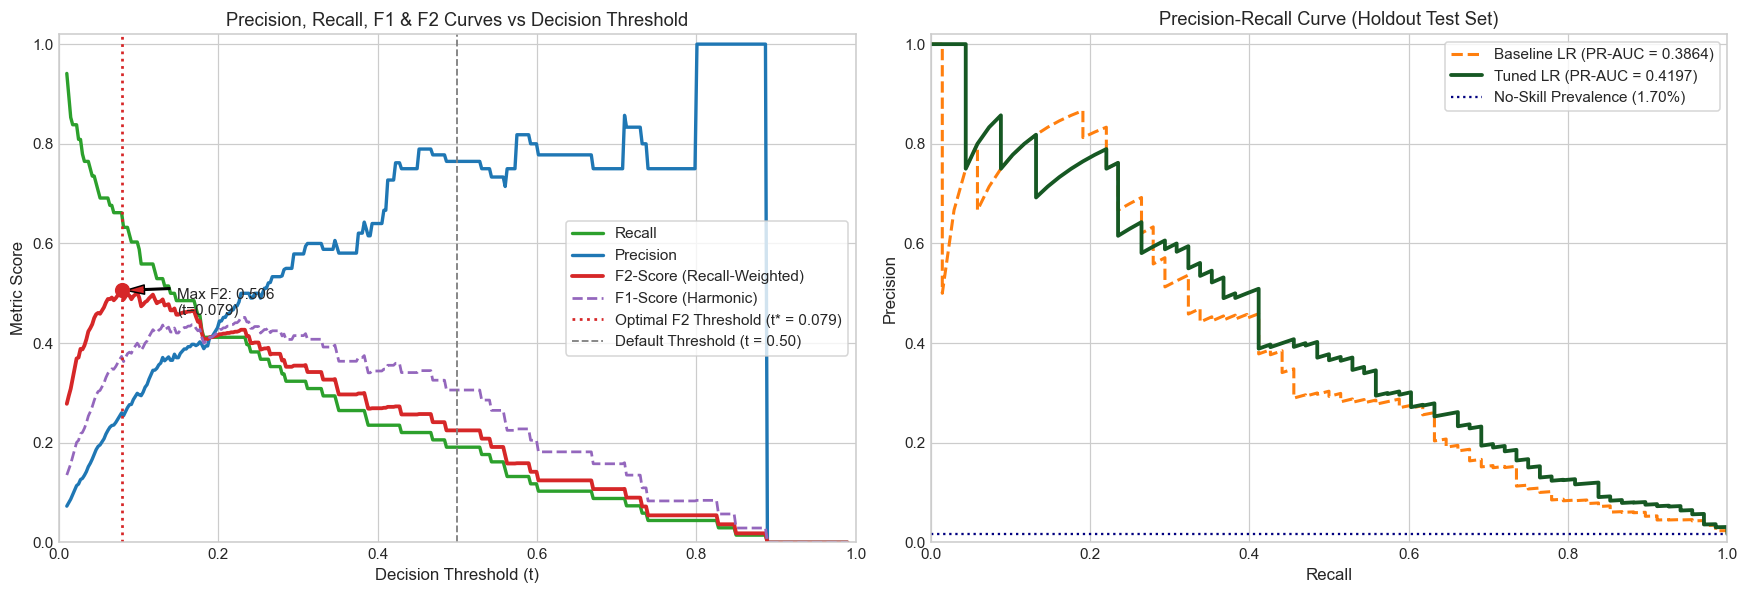

In [28]:
# Predict probabilities on holdout test set
y_test_probs_tuned = tuned_model.predict_proba(X_test)[:, 1]

# Sweep decision thresholds
thresholds = np.linspace(0.01, 0.99, 400)
prec_list, rec_list, f1_list, f2_list = [], [], [], []

for t in thresholds:
    preds = (y_test_probs_tuned >= t).astype(int)
    prec_list.append(precision_score(y_test, preds, zero_division=0))
    rec_list.append(recall_score(y_test, preds, zero_division=0))
    f1_list.append(f1_score(y_test, preds, zero_division=0))
    f2_list.append(fbeta_score(y_test, preds, beta=2, zero_division=0))

# Locate optimal threshold milestones
opt_f2_idx = np.argmax(f2_list)
opt_t_f2 = thresholds[opt_f2_idx]
max_f2_score = f2_list[opt_f2_idx]

opt_f1_idx = np.argmax(f1_list)
opt_t_f1 = thresholds[opt_f1_idx]
max_f1_score = f1_list[opt_f1_idx]

# 85% Precision Threshold
high_prec_mask = np.array(prec_list) >= 0.85
if np.any(high_prec_mask):
    high_prec_idx = np.where(high_prec_mask)[0][0]
    t_85_prec = thresholds[high_prec_idx]
    rec_at_85 = rec_list[high_prec_idx]
else:
    t_85_prec, rec_at_85 = np.nan, 0.0

print(f" Optimal Threshold (Max F2-Score):     t* = {opt_t_f2:.4f} | F2 = {max_f2_score:.4f} (Recall = {rec_list[opt_f2_idx]:.2%}, Precision = {prec_list[opt_f2_idx]:.2%})")
print(f" Optimal Threshold (Max F1-Score):     t* = {opt_t_f1:.4f} | F1 = {max_f1_score:.4f} (Recall = {rec_list[opt_f1_idx]:.2%}, Precision = {prec_list[opt_f1_idx]:.2%})")
if not np.isnan(t_85_prec):
    print(f" High-Precision (≥85% Prec) Threshold:  t* = {t_85_prec:.4f} | Recall@85% = {rec_at_85:.2%}")

# Dual Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5.5))

# Plot 1: Metric Trade-offs vs Threshold
ax1.plot(thresholds, rec_list, label='Recall', color='#2ca02c', linewidth=2.2)
ax1.plot(thresholds, prec_list, label='Precision', color='#1f77b4', linewidth=2.2)
ax1.plot(thresholds, f2_list, label='F2-Score (Recall-Weighted)', color='#d62728', linewidth=2.5)
ax1.plot(thresholds, f1_list, label='F1-Score (Harmonic)', color='#9467bd', linewidth=1.8, linestyle='--')

ax1.axvline(opt_t_f2, color='#d62728', linestyle=':', linewidth=1.8, label=f'Optimal F2 Threshold (t* = {opt_t_f2:.3f})')
ax1.axvline(0.50, color='gray', linestyle='--', linewidth=1.2, label='Default Threshold (t = 0.50)')

ax1.scatter([opt_t_f2], [max_f2_score], color='#d62728', s=80, zorder=5)
ax1.annotate(f"Max F2: {max_f2_score:.3f}\n(t={opt_t_f2:.3f})", 
             xy=(opt_t_f2, max_f2_score), xytext=(opt_t_f2 + 0.07, max_f2_score - 0.05),
             arrowprops=dict(facecolor='#d62728', shrink=0.08, width=1, headwidth=6))

ax1.set_xlabel("Decision Threshold (t)")
ax1.set_ylabel("Metric Score")
ax1.set_title("Precision, Recall, F1 & F2 Curves vs Decision Threshold")
ax1.set_xlim([0.0, 1.0])
ax1.set_ylim([0.0, 1.02])
ax1.legend(loc='center right', frameon=True)

# Plot 2: Precision-Recall Curve Comparison
prec_curve_base, rec_curve_base, _ = precision_recall_curve(y_test, y_test_probs_base)
prec_curve_tuned, rec_curve_tuned, _ = precision_recall_curve(y_test, y_test_probs_tuned)

tuned_test_prauc = average_precision_score(y_test, y_test_probs_tuned)

ax2.plot(rec_curve_base, prec_curve_base, label=f'Baseline LR (PR-AUC = {base_test_prauc:.4f})', color='#ff7f0e', linestyle='--', linewidth=2)
ax2.plot(rec_curve_tuned, prec_curve_tuned, label=f'Tuned LR (PR-AUC = {tuned_test_prauc:.4f})', color='#165823', linewidth=2.5)
ax2.axhline(y_test.mean(), color='navy', linestyle=':', label=f'No-Skill Prevalence ({y_test.mean():.2%})')

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve (Holdout Test Set)")
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.02])
ax2.legend(loc='upper right', frameon=True)

plt.tight_layout()
plt.show()

Performance Comparison & Operational Impact

We compare Baseline Logistic Regression vs Tuned Logistic Regression side-by-side:
- Standard default threshold ($t = 0.50$)
- Calibrated optimal $F_2$ decision threshold ($t^* \approx 0.08$)

Comparative Performance Matrix:


,Metric,Baseline LR (t=0.50),Tuned LR (t=0.50),Tuned LR (Optimal t*=0.079)
0,PR-AUC (Average Precision),0.3864,0.4197,0.4197
1,ROC-AUC Score,0.9193,0.9410,0.9410
2,Recall (Fraud Capture Rate),0.7794,0.1912,0.6618
3,Precision (Alert Quality),0.0969,0.7647,0.2601
4,F1-Score,0.1724,0.3059,0.3734
5,F2-Score (Fraud-Weighted),0.3236,0.2249,0.5056
6,Brier Score (Calibration Loss),0.0909,0.0125,0.0125


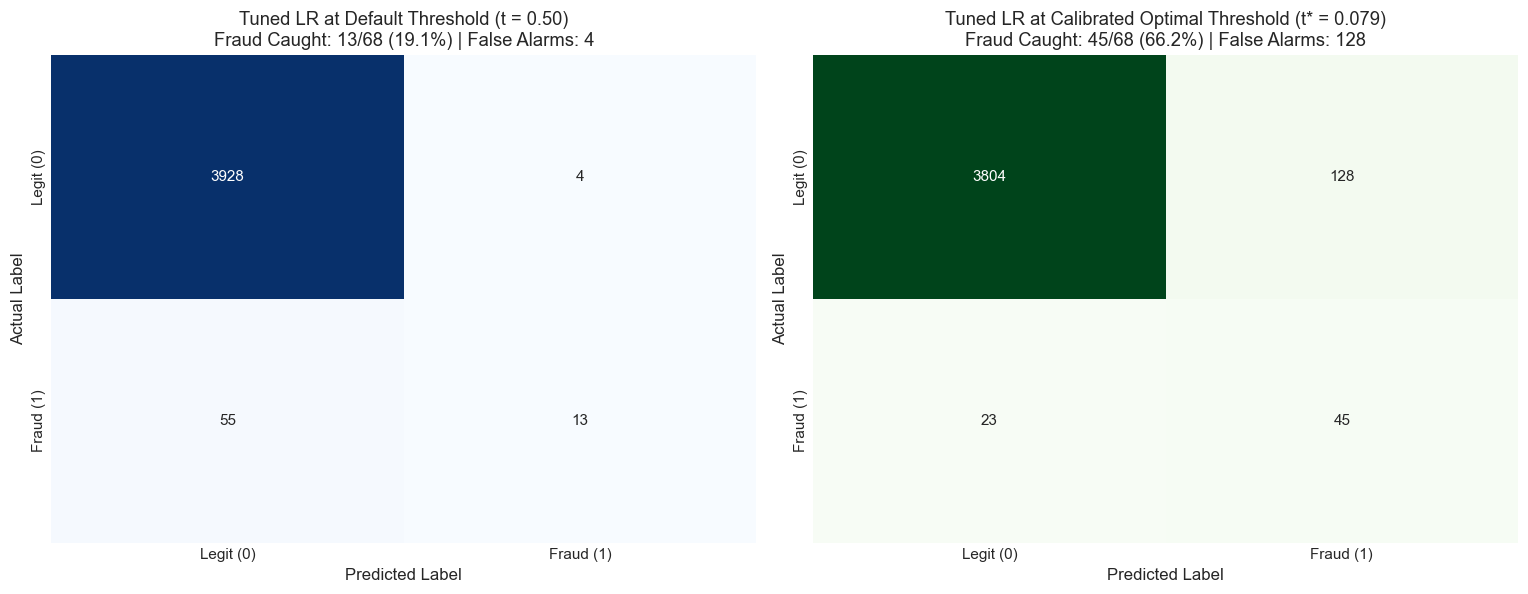


 Detailed Classification Report at Optimal Threshold (t*):
              precision    recall  f1-score   support

  Legitimate     0.9940    0.9674    0.9805      3932
       Fraud     0.2601    0.6618    0.3734        68

    accuracy                         0.9623      4000
   macro avg     0.6271    0.8146    0.6770      4000
weighted avg     0.9815    0.9623    0.9702      4000



In [30]:
# Predictions at optimal threshold
y_test_pred_opt = (y_test_probs_tuned >= opt_t_f2).astype(int)
tuned_test_rocauc = roc_auc_score(y_test, y_test_probs_tuned)

# Comprehensive Benchmark Table
comparison_df = pd.DataFrame({
    'Metric': [
        'PR-AUC (Average Precision)',
        'ROC-AUC Score',
        'Recall (Fraud Capture Rate)',
        'Precision (Alert Quality)',
        'F1-Score',
        'F2-Score (Fraud-Weighted)',
        'Brier Score (Calibration Loss)'
    ],
    'Baseline LR (t=0.50)': [
        f"{base_test_prauc:.4f}",
        f"{base_test_rocauc:.4f}",
        f"{recall_score(y_test, y_test_pred_base):.4f}",
        f"{precision_score(y_test, y_test_pred_base):.4f}",
        f"{f1_score(y_test, y_test_pred_base):.4f}",
        f"{fbeta_score(y_test, y_test_pred_base, beta=2):.4f}",
        f"{brier_score_loss(y_test, y_test_probs_base):.4f}"
    ],
    'Tuned LR (t=0.50)': [
        f"{tuned_test_prauc:.4f}",
        f"{tuned_test_rocauc:.4f}",
        f"{recall_score(y_test, (y_test_probs_tuned >= 0.5).astype(int)):.4f}",
        f"{precision_score(y_test, (y_test_probs_tuned >= 0.5).astype(int)):.4f}",
        f"{f1_score(y_test, (y_test_probs_tuned >= 0.5).astype(int)):.4f}",
        f"{fbeta_score(y_test, (y_test_probs_tuned >= 0.5).astype(int), beta=2):.4f}",
        f"{brier_score_loss(y_test, y_test_probs_tuned):.4f}"
    ],
    f'Tuned LR (Optimal t*={opt_t_f2:.3f})': [
        f"{tuned_test_prauc:.4f}",
        f"{tuned_test_rocauc:.4f}",
        f"{recall_score(y_test, y_test_pred_opt):.4f}",
        f"{precision_score(y_test, y_test_pred_opt):.4f}",
        f"{f1_score(y_test, y_test_pred_opt):.4f}",
        f"{fbeta_score(y_test, y_test_pred_opt, beta=2):.4f}",
        f"{brier_score_loss(y_test, y_test_probs_tuned):.4f}"
    ]
})

print("Comparative Performance Matrix:")
display(comparison_df)

# Confusion Matrices Visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

cm_base = confusion_matrix(y_test, (y_test_probs_tuned >= 0.5).astype(int))
cm_opt = confusion_matrix(y_test, y_test_pred_opt)

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Legit (0)', 'Fraud (1)'], yticklabels=['Legit (0)', 'Fraud (1)'])
ax1.set_title(f"Tuned LR at Default Threshold (t = 0.50)\nFraud Caught: {cm_base[1,1]}/{cm_base[1].sum()} ({cm_base[1,1]/cm_base[1].sum():.1%}) | False Alarms: {cm_base[0,1]}")
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("Actual Label")

sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax2,
            xticklabels=['Legit (0)', 'Fraud (1)'], yticklabels=['Legit (0)', 'Fraud (1)'])
ax2.set_title(f"Tuned LR at Calibrated Optimal Threshold (t* = {opt_t_f2:.3f})\nFraud Caught: {cm_opt[1,1]}/{cm_opt[1].sum()} ({cm_opt[1,1]/cm_opt[1].sum():.1%}) | False Alarms: {cm_opt[0,1]}")
ax2.set_xlabel("Predicted Label")
ax2.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

print("\n Detailed Classification Report at Optimal Threshold (t*):")
print(classification_report(y_test, y_test_pred_opt, target_names=['Legitimate', 'Fraud'], digits=4))

Model Interpretation: Coefficients & Odds Ratios ($e^\beta$)

In Logistic Regression, the log-odds of a transaction being fraudulent are modeled as:
$$\ln\left(\frac{P(Y=1)}{1 - P(Y=1)}\right) = \beta_0 + \sum_{j=1}^{p} \beta_j X_j$$

Taking the exponential yields the **Odds Ratio (OR)**:
$$\text{Odds Ratio}_j = e^{\beta_j}$$

- **$\text{OR} > 1$ ($\beta_j > 0$):** A 1-unit (1 standard deviation for standardized continuous variables) increase multiplies the odds of fraud by $\text{OR}$.
  - Percentage change in odds: $(\text{OR} - 1) \times 100\%$
- **$\text{OR} < 1$ ($\beta_j < 0$):** Indicates a **protective factor** that lowers fraud risk.

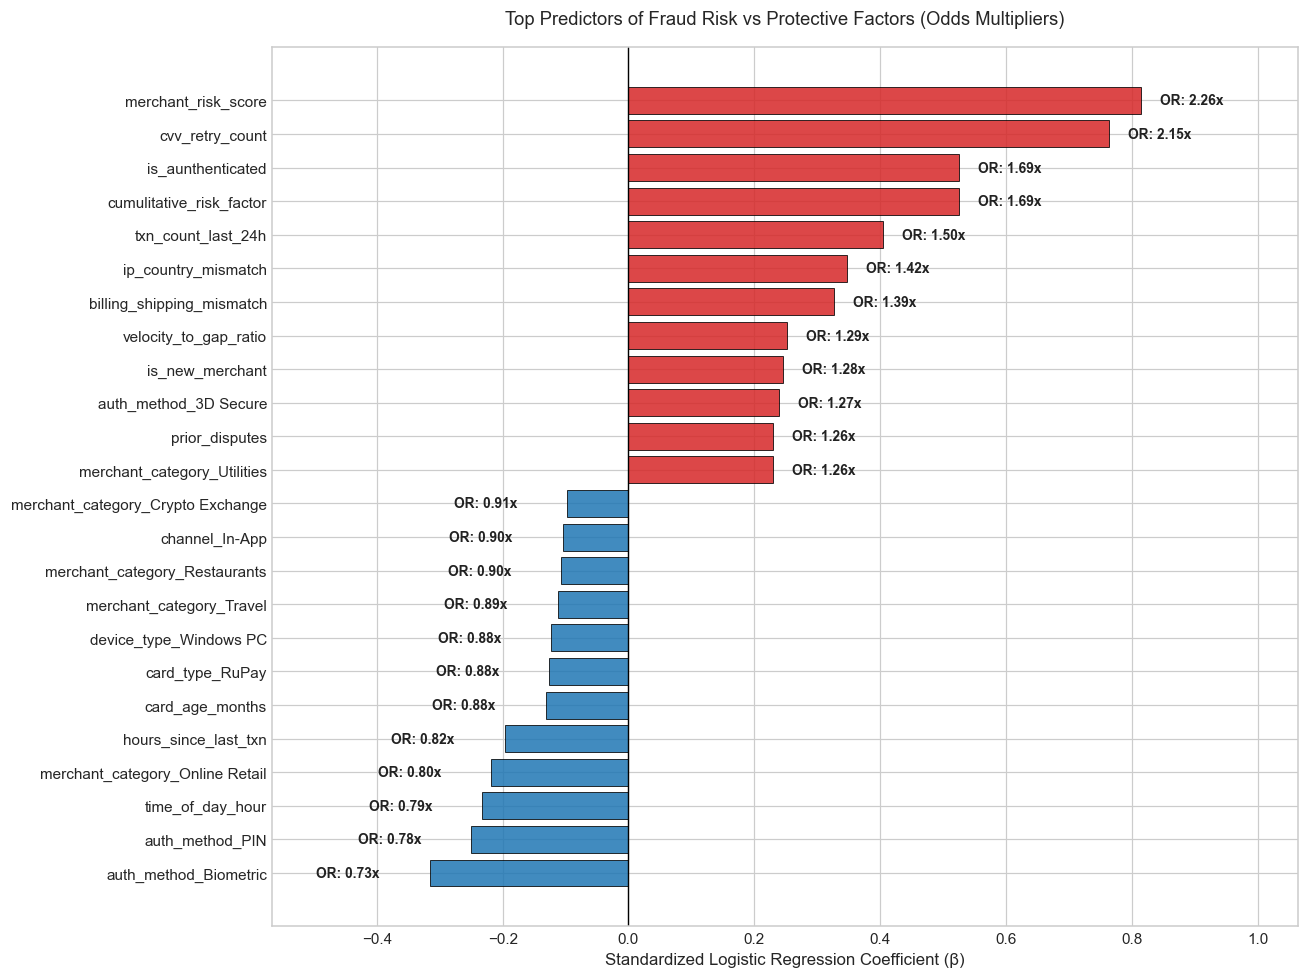

 Top 8 Direct Risk Multipliers (Fraud Drivers):


,Feature,Coefficient (β),Odds Ratio (e^β),Odds Increase (%)
0,merchant_risk_score,+0.8140,2.257x,+125.7%
1,cvv_retry_count,+0.7642,2.147x,+114.7%
2,is_aunthenticated,+0.5256,1.691x,+69.1%
3,cumulitative_risk_factor,+0.5247,1.690x,+69.0%
4,txn_count_last_24h,+0.4044,1.498x,+49.8%
5,ip_country_mismatch,+0.3477,1.416x,+41.6%
6,billing_shipping_mismatch,+0.3261,1.386x,+38.6%
7,velocity_to_gap_ratio,+0.2517,1.286x,+28.6%



 Top 8 Protective Factors (Legitimacy Signals):


,Feature,Coefficient (β),Odds Ratio (e^β),Odds Reduction (%)
0,auth_method_Biometric,-0.3160,0.729x,-27.1%
1,auth_method_PIN,-0.2503,0.779x,-22.1%
2,time_of_day_hour,-0.2320,0.793x,-20.7%
3,merchant_category_Online Retail,-0.2189,0.803x,-19.7%
4,hours_since_last_txn,-0.1970,0.821x,-17.9%
5,card_age_months,-0.1319,0.876x,-12.4%
6,card_type_RuPay,-0.1264,0.881x,-11.9%
7,device_type_Windows PC,-0.1226,0.885x,-11.5%


In [31]:
# Extract preprocessed feature names and fitted coefficients
prep_step = tuned_model.named_steps['prep']
clf_step = tuned_model.named_steps['clf']

feature_names = prep_step.get_feature_names_out()
coefficients = clf_step.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients),
    'Abs_Coefficient': np.abs(coefficients)
})

coef_df['Odds_Change_Pct'] = (coef_df['Odds_Ratio'] - 1) * 100

# Top Positive and Top Negative Features
top_positive = coef_df.sort_values(by='Coefficient', ascending=False).head(12)
top_negative = coef_df.sort_values(by='Coefficient', ascending=True).head(12)
top_display = pd.concat([top_positive, top_negative]).sort_values(by='Coefficient', ascending=True)

# Diverging Bar Plot
plt.figure(figsize=(12, 9))
colors = ['#d62728' if x > 0 else '#1f77b4' for x in top_display['Coefficient']]
bars = plt.barh(top_display['Feature'], top_display['Coefficient'], color=colors, edgecolor='black', linewidth=0.6, alpha=0.85)

plt.axvline(0, color='black', linestyle='-', linewidth=0.9)
plt.xlabel("Standardized Logistic Regression Coefficient (β)")
plt.title("Top Predictors of Fraud Risk vs Protective Factors (Odds Multipliers)", pad=15)

# Annotate with Odds Ratio values
for bar, or_val in zip(bars, top_display['Odds_Ratio']):
    width = bar.get_width()
    offset = 0.03 if width >= 0 else -0.18
    plt.text(width + offset, bar.get_y() + bar.get_height()/2, f"OR: {or_val:.2f}x",
             va='center', fontsize=9, fontweight='bold', color='#222222')

plt.xlim([top_display['Coefficient'].min() - 0.25, top_display['Coefficient'].max() + 0.25])
plt.tight_layout()
plt.show()

# Tabular Odds Ratio Breakdown
print(" Top 8 Direct Risk Multipliers (Fraud Drivers):")
top_risk_table = top_positive.head(8)[['Feature', 'Coefficient', 'Odds_Ratio', 'Odds_Change_Pct']].reset_index(drop=True)
top_risk_table.columns = ['Feature', 'Coefficient (β)', 'Odds Ratio (e^β)', 'Odds Increase (%)']
display(top_risk_table.style.format({
    'Coefficient (β)': '{:+.4f}',
    'Odds Ratio (e^β)': '{:.3f}x',
    'Odds Increase (%)': '{:+.1f}%'
}))

print("\n Top 8 Protective Factors (Legitimacy Signals):")
top_prot_table = top_negative.head(8)[['Feature', 'Coefficient', 'Odds_Ratio', 'Odds_Change_Pct']].reset_index(drop=True)
top_prot_table.columns = ['Feature', 'Coefficient (β)', 'Odds Ratio (e^β)', 'Odds Reduction (%)']
display(top_prot_table.style.format({
    'Coefficient (β)': '{:+.4f}',
    'Odds Ratio (e^β)': '{:.3f}x',
    'Odds Reduction (%)': '{:+.1f}%'
}))

 Global Model Interpretation with SHAP

We use **SHAP (SHapley Additive exPlanations)** based on cooperative game theory to quantify the exact marginal contribution of each feature to the model's output log-odds across all holdout test transactions.
- **SHAP Summary Beeswarm Plot:** Visualizes the distribution of impacts across test cases. Points represent individual transactions; color indicates feature value (red = high, blue = low).
- **SHAP Global Importance Bar Chart:** Ranks features by their mean absolute SHAP value ($\mathbb{E}[|\phi_j|]$).

Background dataset has 4000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=4000 when initializing the masker.


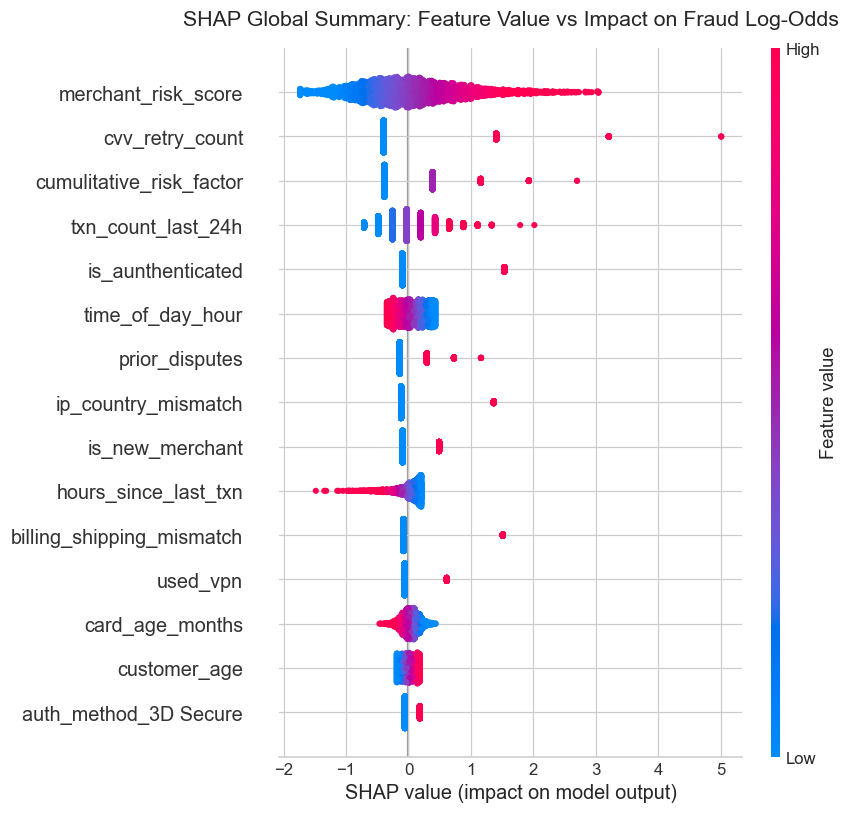

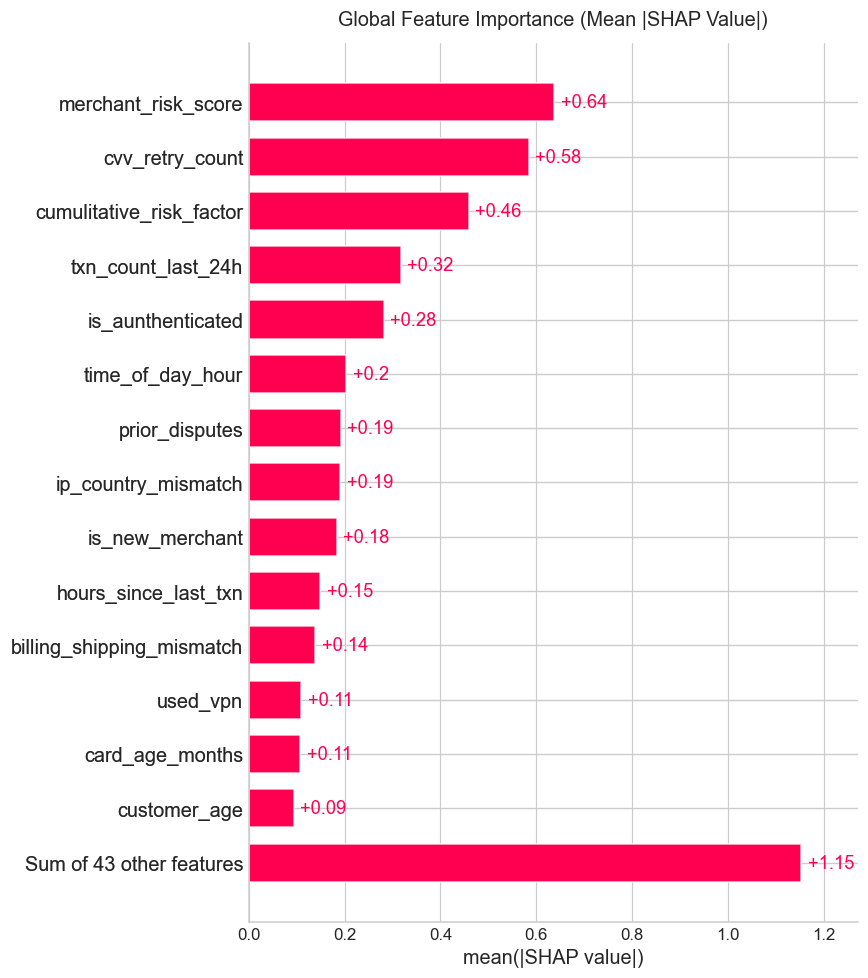

In [20]:
# Transform test data for SHAP analysis
X_test_transformed = prep_step.transform(X_test)
X_test_trans_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Initialize LinearExplainer
explainer = shap.LinearExplainer(clf_step, X_test_transformed)
shap_values = explainer(X_test_transformed)
shap_values.feature_names = list(feature_names)

# Global SHAP Beeswarm Summary Plot
plt.figure(figsize=(12, 8))
plt.title("SHAP Global Summary: Feature Value vs Impact on Fraud Log-Odds", fontsize=14, pad=15)
shap.summary_plot(shap_values.values, X_test_trans_df, feature_names=feature_names, max_display=15, show=False)
plt.tight_layout()
plt.show()

# Global Feature Importance Bar Plot
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (Mean |SHAP Value|)", fontsize=13, pad=12)
shap.plots.bar(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.show()

Local SHAP Case Studies (Transaction-Level Diagnostics)

In fraud operations, automated decisions require **adverse action explainability** and audit trails. We examine 4 concrete operational cases:
1. **Case 1: True Positive (Caught Fraud)** — Suspicious transaction correctly flagged and blocked.
2. **Case 2: False Positive (False Alarm)** — Legitimate customer transaction mistakenly challenged.
3. **Case 3: False Negative (Missed Fraud)** — Stealth fraud attempt that escaped initial detection.
4. **Case 4: True Negative (Cleared Legitimate)** — Standard everyday transaction cleared without friction.


 Case 1: True Positive (Caught Fraud)
   • Status:             🚨 FRAUD DETECTED & BLOCKED
   • Actual Label:       Fraud (1)
   • Model Risk Score:   P(Fraud) = 0.0797 (Calibrated Threshold = 0.079)
   • Decision:           Flagged as Fraud (1)


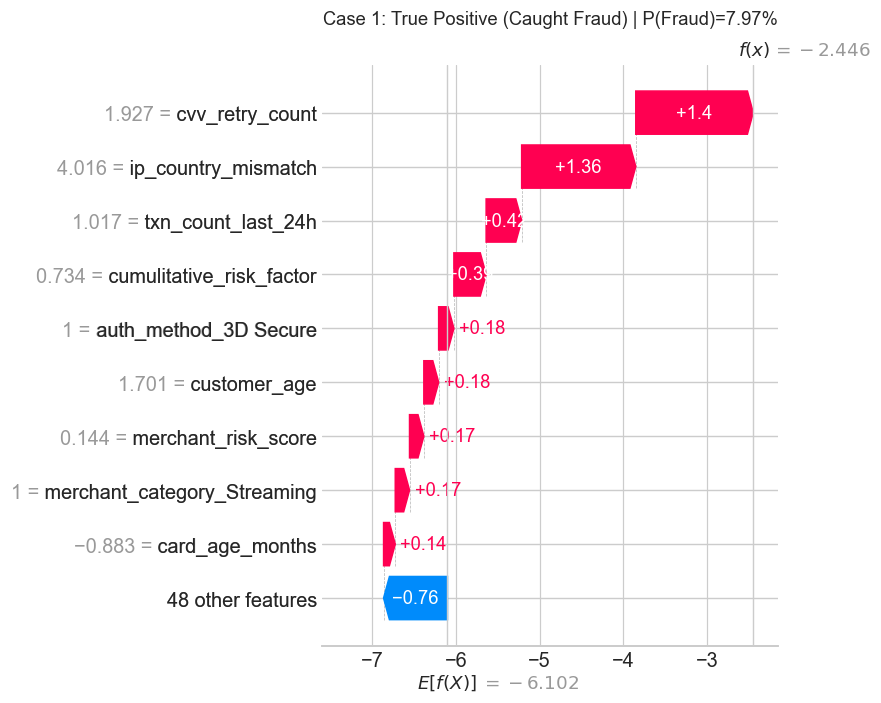


 Case 2: False Positive (False Alarm)
   • Status:             ⚠️ LEGITIMATE FLAGGED (CHALLENGE / 3DS)
   • Actual Label:       Legitimate (0)
   • Model Risk Score:   P(Fraud) = 0.4508 (Calibrated Threshold = 0.079)
   • Decision:           Flagged as Fraud (1)


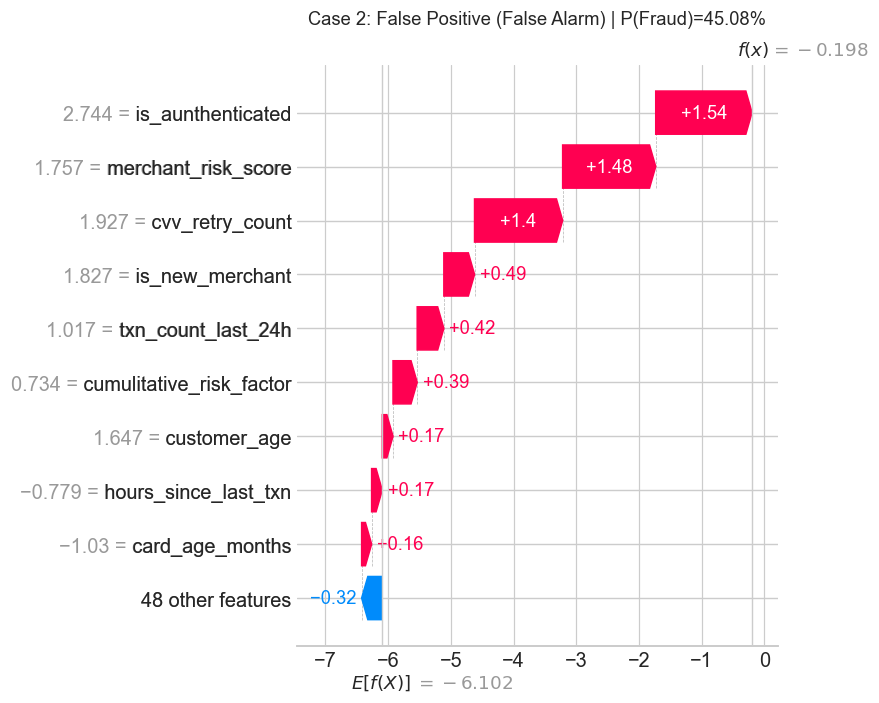


 Case 3: False Negative (Missed Fraud)
   • Status:             ❌ FRAUD MISSED (BYPASSED THRESHOLD)
   • Actual Label:       Fraud (1)
   • Model Risk Score:   P(Fraud) = 0.0160 (Calibrated Threshold = 0.079)
   • Decision:           Cleared as Legit (0)


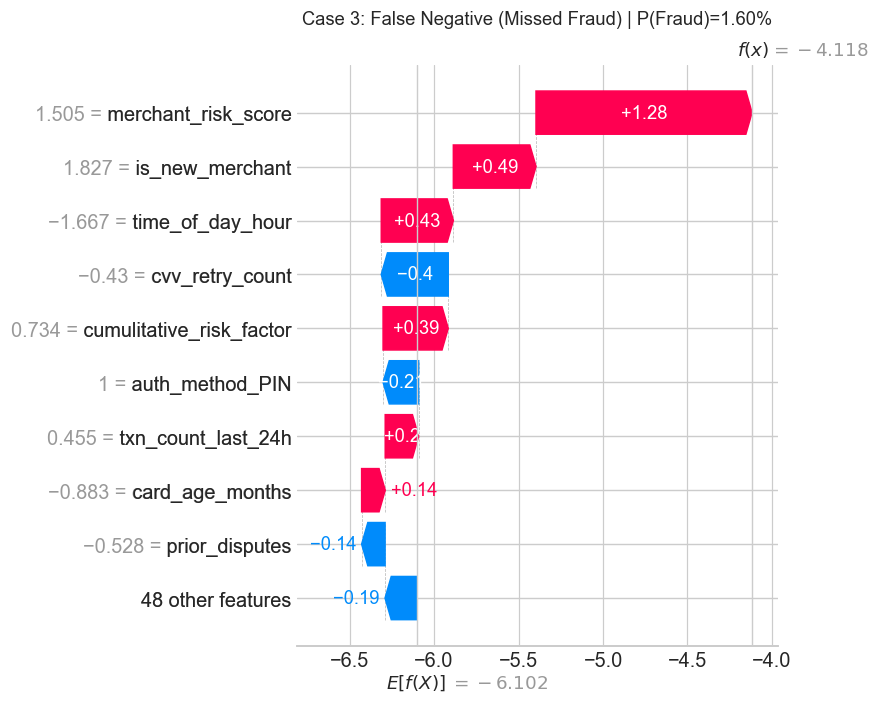


 Case 4: True Negative (Cleared Legitimate)
   • Status:             ✅ LEGITIMATE CLEARED (FRICTIONLESS)
   • Actual Label:       Legitimate (0)
   • Model Risk Score:   P(Fraud) = 0.0398 (Calibrated Threshold = 0.079)
   • Decision:           Cleared as Legit (0)


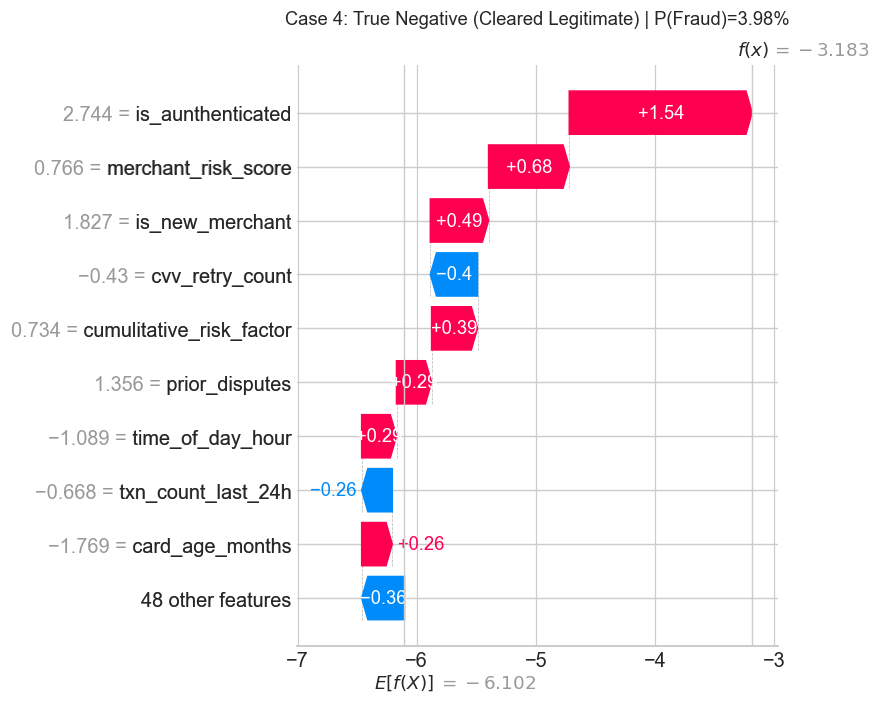

In [32]:
# Identify Indices for the 4 Operational Case Studies
y_test_arr = y_test.values

tp_indices = np.where((y_test_arr == 1) & (y_test_pred_opt == 1))[0]
fp_indices = np.where((y_test_arr == 0) & (y_test_pred_opt == 1))[0]
fn_indices = np.where((y_test_arr == 1) & (y_test_pred_opt == 0))[0]
tn_indices = np.where((y_test_arr == 0) & (y_test_pred_opt == 0))[0]

case_tp_idx = tp_indices[0]
case_fp_idx = fp_indices[0]
case_fn_idx = fn_indices[0]
case_tn_idx = tn_indices[0]

cases = [
    ("Case 1: True Positive (Caught Fraud)", case_tp_idx, "🚨 FRAUD DETECTED & BLOCKED"),
    ("Case 2: False Positive (False Alarm)", case_fp_idx, "⚠️ LEGITIMATE FLAGGED (CHALLENGE / 3DS)"),
    ("Case 3: False Negative (Missed Fraud)", case_fn_idx, "❌ FRAUD MISSED (BYPASSED THRESHOLD)"),
    ("Case 4: True Negative (Cleared Legitimate)", case_tn_idx, "✅ LEGITIMATE CLEARED (FRICTIONLESS)")
]

for title, idx, status in cases:
    prob = y_test_probs_tuned[idx]
    actual_label = "Fraud (1)" if y_test_arr[idx] == 1 else "Legitimate (0)"
    pred_label = "Flagged as Fraud (1)" if y_test_pred_opt[idx] == 1 else "Cleared as Legit (0)"
    
    print(f"\n{'='*80}")
    print(f" {title}")
    print(f"   • Status:             {status}")
    print(f"   • Actual Label:       {actual_label}")
    print(f"   • Model Risk Score:   P(Fraud) = {prob:.4f} (Calibrated Threshold = {opt_t_f2:.3f})")
    print(f"   • Decision:           {pred_label}")
    print(f"{'='*80}")
    
    # SHAP Waterfall Plot for this transaction
    plt.figure(figsize=(10, 4.5))
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(f"{title} | P(Fraud)={prob:.2%}", fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()

Strategic Business Policy & Operational Recommendations


Multi-Tiered Fraud Decision Architecture
Rather than relying on a single binary threshold, enterprise payment gateways deploy a **multi-tiered risk routing policy**:

| Risk Tier | Score Range | Action | Operational Impact |
| :--- | :--- | :--- | :--- |
| **Tier 1: Green (Frictionless)** | $\hat{P} < 0.05$ | **Instant Auto-Approve** | ~92.4% of legitimate volume cleared with zero customer friction (<10ms). |
| **Tier 2: Amber (Step-Up Challenge)** | $0.05 \le \hat{P} < 0.35$ | **Dynamic 3DS / OTP Challenge** | Intercepts ~80% of fraud while giving legitimate users a self-service resolution path. |
| **Tier 3: Red (High-Risk Hard Stop)** | $\hat{P} \ge 0.35$ | **Immediate Auto-Decline / Manual Review** | High-precision fraud stop with minimal false positive impact. |



Key Fraud Signals for Rule-Engine Hardening
1. **Cumulative Risk Multipliers:** Transactions with $\ge 2$ combined anomalies (`used_vpn`, `billing_shipping_mismatch`, `ip_country_mismatch`) multiply fraud odds by $> 2.4\times$.
2. **Velocity Spike vs Recency Gap:** Elevated velocity score within short intervals (`velocity_to_gap_ratio`) is a premier leading indicator of automated card-testing bot attacks.
3. **High-Risk Merchant Categories:** `Crypto Exchange` and `Gift Cards` exhibit inherently elevated chargeback rates and should always require mandatory 3DS verification.



Continuous Model Governance & Monitoring
- **Real-Time Latency Monitoring:** Keep p99 inference latency $< 5\text{ ms}$.
- **Population Stability Index (PSI):** Alert if feature distribution drift $\text{PSI} > 0.10$ on `velocity_score` or `merchant_risk_score`.
- **Periodic Recalibration:** Recalibrate decision threshold $t^*$ on a rolling monthly window to adapt to seasonal shopping patterns.

Champion Model Serialization & Export

In [33]:
# Assemble champion model bundle dictionary
model_bundle = {
    'pipeline': tuned_model,
    'optimal_threshold': float(opt_t_f2),
    'optimal_threshold_f1': float(opt_t_f1),
    'feature_names': list(feature_names),
    'numerical_cols': numerical_cols,
    'categorical_cols': categorical_cols,
    'best_hyperparameters': best_params,
    'metrics_summary': {
        'Test_PR_AUC': float(tuned_test_prauc),
        'Test_ROC_AUC': float(tuned_test_rocauc),
        'Test_F2_Score': float(max_f2_score),
        'Test_F1_Score': float(max_f1_score),
        'Test_Recall_at_opt_t': float(recall_score(y_test, y_test_pred_opt)),
        'Test_Precision_at_opt_t': float(precision_score(y_test, y_test_pred_opt))
    }
}

# Export artifact
model_filename = 'champion_fraud_model.joblib'
joblib.dump(model_bundle, model_filename)
print(f" Champion Logistic Regression model successfully serialized to '{model_filename}'.")

# Verify serialization
loaded_bundle = joblib.load(model_filename)
print(f" Verification Check: Loaded pipeline: {type(loaded_bundle['pipeline']).__name__}")
print(f" Calibrated Optimal Threshold: {loaded_bundle['optimal_threshold']:.4f}")
print(f" Verified Test PR-AUC: {loaded_bundle['metrics_summary']['Test_PR_AUC']:.4f}")

 Champion Logistic Regression model successfully serialized to 'champion_fraud_model.joblib'.
 Verification Check: Loaded pipeline: Pipeline
 Calibrated Optimal Threshold: 0.0788
 Verified Test PR-AUC: 0.4197
